# Circuit 7 — Dynamical Decoupling: Baseline vs XY-4 (8 qubits)

**What it does:** Demonstrates dynamical decoupling (DD) suppressing idle-time
decoherence. An 8-qubit GHZ state is prepared, stored across 20 idle layers,
then un-prepared with the inverse GHZ circuit. Two variants are compared:

- **Baseline** — no DD; qubits accumulate T2 dephasing and quasi-static Z drift
  during the storage window
- **XY-4 DD** — the idle window is filled with an XY-4 pulse sequence
  (X·Y·X·Y), which refocuses quasi-static Z rotations and suppresses dephasing

**Build order (critical):**
1. Build the *sparse* circuit with explicit `t=` values and no IDLE ops
2. `apply_dd(sparse, sequence="XY-4")` — fills idle gaps with DD pulses
3. `fill_idle_with_identities(both)` — adds IDLE ops so noise ticks during idle slots

**Noise profile:** `demo_profile_dd` adds `idle_coherent_epsilon=0.07 rad` per
idle slot — a quasi-static Z detuning (~1.4 MHz ZZ detuning, realistic for Eagle r3)
that XY-4 can actually refocus. Without it DD has nothing to suppress.

**All-Clifford:** H, CNOT, X, Y — `ManyShotRunner` uses both circuits directly.
8 qubits is within `TrajectoryBackend`'s 13-qubit limit, so purity passes run normally.

In [1]:
import os
import dataclasses
import numpy as np
import matplotlib.pyplot as plt

import noisiq as nq
from noisiq.backends import TrajectoryBackend, ManyShotRunner
from noisiq.suppression import apply_dd
from noisiq.noise import fill_idle_with_identities
from noisiq.visualization import (
    Visualizer,
    export_gif,
    interactive_heatmap,
    plot_error_heatmap,
    per_qubit_purities,
    add_purity_panel,
)

os.makedirs("outputs", exist_ok=True)

profile    = nq.noise.get_hardware("ibm_eagle_r3")
gate_times = profile.gate_times

# demo_profile_dd adds quasi-static Z component (0.07 rad per idle slot)
# so XY-4 has a coherent error source to actually refocus.
demo_profile_dd = dataclasses.replace(profile, idle_coherent_epsilon=0.07)

N_SHOTS      = 2000
N_SHOTS_TRAJ = 400

print(f"noisiq {nq.__version__}")
print(profile.describe())

noisiq 0.1.0
{'name': 'ibm_eagle_r3', 'vendor': 'IBM', 'system': 'Eagle r3', 't1_us': 262.0, 't2_us': 177.0, 'single_qubit_error': 0.00024, 'two_qubit_error': 0.0074, 'spam_error': 0.0135, 'gate_times_ns': {'1q': 60.0, '2q': 533.0}, 'ghz_results': [{'n_qubits': 127, 'fidelity': 0.546, 'year': 2023, 'source': 'arXiv:2101.08946'}, {'n_qubits': 27, 'fidelity': 0.546, 'year': 2021, 'source': 'arXiv:2101.08946'}, {'n_qubits': 18, 'fidelity': 0.5165, 'year': 2019, 'source': 'arXiv:1905.05720'}]}


In [2]:
def run_purity_pass(circuit, noise_config_twirl, n_qubits, label=""):
    result_traj = TrajectoryBackend().run(
        circuit, noise_model=noise_config_twirl, n_shots=N_SHOTS_TRAJ, seed=42,
    )
    rho = result_traj.final_state
    purities = per_qubit_purities(rho, n_qubits)
    print(f"\n{'─'*50}")
    print(f"Per-qubit purity  [{label}]")
    for q, p in enumerate(purities):
        print(f"  q{q:>2d}  Tr(ρ²) = {p:.4f}  {'█' * int(p * 20)}")
    print(f"{'─'*50}\n")
    return rho, purities


def visualize_circuit(circuit, result_many, noise_pauli, rho, purities,
                      label, gif_name):
    fig = plot_error_heatmap(
        result_many, circuit, noise_config=noise_pauli,
        title=f"IBM Eagle r3 · {label}",
    )
    add_purity_panel(fig, fig.axes[0], rho, circuit.n_qubits)
    plt.show()

    interactive_heatmap(
        result_many, circuit, noise_config=noise_pauli,
        display_mode="annotate",
        title=f"IBM Eagle r3 · {label} [interactive]",
    )
    plt.show()

    viz = Visualizer(circuit)
    viz.many_shot_result = result_many
    gif_path = f"outputs/{gif_name}.gif"
    export_gif(viz, gif_path, purities=purities)
    print(f"GIF → {gif_path}")


print("Helpers ready.")

Helpers ready.


In [3]:
N_DD           = 8   # qubits
STORAGE_LAYERS = 20  # idle layers between GHZ and inverse-GHZ
ENTANGLE_DEPTH = N_DD - 1  # CNOTs span t=1..N_DD-1; H at t=0


def build_sparse_dd_circuit(n: int, storage: int) -> nq.Circuit:
    """
    GHZ-n + [storage idle layers] + inverse GHZ-n.
    All gate times are explicit so apply_dd can detect the idle gap.
    No IDLE ops yet — fill_idle_with_identities adds those afterward.
    """
    c = nq.Circuit(n_qubits=n, name=f"dd_storage_{n}q")

    # GHZ prep: t = 0 … N_DD-1
    c.h(0, t=0)
    for i in range(n - 1):
        c.cnot(i, i + 1, t=i + 1)

    # Storage gap: t = N_DD … N_DD + STORAGE_LAYERS - 1  (intentionally empty)

    end_t = ENTANGLE_DEPTH + storage  # first slot of inverse GHZ

    # Inverse GHZ: reverse CNOT order, then H
    for i in reversed(range(n - 1)):
        c.cnot(i, i + 1, t=end_t + (n - 1 - i))
    c.h(0, t=end_t + n)

    return c


# Step 1 — sparse base circuit (no IDLE ops)
circuit_dd_sparse = build_sparse_dd_circuit(N_DD, STORAGE_LAYERS)

# Step 2 — apply XY-4 on a copy; fills idle windows with X, Y pulses
circuit_dd_xy4_sparse = apply_dd(
    circuit_dd_sparse, sequence="XY-4", idle_threshold=4
)

print(f"Sparse baseline ops: {len(circuit_dd_sparse.operations)}")
print(f"Sparse XY-4 ops:     {len(circuit_dd_xy4_sparse.operations)}")

# Step 3 — fill IDLE ops so noise ticks during idle periods
circuit_baseline = fill_idle_with_identities(circuit_dd_sparse,     gate_times)
circuit_xy4      = fill_idle_with_identities(circuit_dd_xy4_sparse, gate_times)

print(f"Baseline ops (idle-filled): {len(circuit_baseline.operations)}")
print(f"XY-4 ops (idle-filled):     {len(circuit_xy4.operations)}")

Sparse baseline ops: 16
Sparse XY-4 ops:     48
Baseline ops (idle-filled): 274
XY-4 ops (idle-filled):     274


In [4]:
# Use demo_profile_dd (with coherent epsilon) so XY-4 has a drift to refocus.
noise_dd_baseline = demo_profile_dd.to_noise_model(
    circuit_baseline, mode="t2", representation="pauli_twirl",
)
noise_dd_xy4 = demo_profile_dd.to_noise_model(
    circuit_xy4, mode="t2", representation="pauli_twirl",
)

result_dd_baseline = ManyShotRunner().run(
    circuit_baseline, n_shots=N_SHOTS, noise_config=noise_dd_baseline, seed=42,
)
result_dd_xy4 = ManyShotRunner().run(
    circuit_xy4, n_shots=N_SHOTS, noise_config=noise_dd_xy4, seed=42,
)

print(f"Zero-error (baseline): {result_dd_baseline.zero_error_fraction:.4f}")
print(f"Zero-error (XY-4 DD):  {result_dd_xy4.zero_error_fraction:.4f}")

rho_base, pur_base = run_purity_pass(
    circuit_baseline, noise_dd_baseline, N_DD, "DD Baseline"
)
rho_xy4, pur_xy4 = run_purity_pass(
    circuit_xy4, noise_dd_xy4, N_DD, "DD XY-4"
)

Zero-error (baseline): 0.1090
Zero-error (XY-4 DD):  0.1090

──────────────────────────────────────────────────
Per-qubit purity  [DD Baseline]
  q 0  Tr(ρ²) = 0.5000  ██████████
  q 1  Tr(ρ²) = 0.9232  ██████████████████
  q 2  Tr(ρ²) = 0.9186  ██████████████████
  q 3  Tr(ρ²) = 0.9371  ██████████████████
  q 4  Tr(ρ²) = 0.9232  ██████████████████
  q 5  Tr(ρ²) = 0.9232  ██████████████████
  q 6  Tr(ρ²) = 0.9186  ██████████████████
  q 7  Tr(ρ²) = 0.9704  ███████████████████
──────────────────────────────────────────────────


──────────────────────────────────────────────────
Per-qubit purity  [DD XY-4]
  q 0  Tr(ρ²) = 0.5001  ██████████
  q 1  Tr(ρ²) = 0.9140  ██████████████████
  q 2  Tr(ρ²) = 0.9050  ██████████████████
  q 3  Tr(ρ²) = 0.9418  ██████████████████
  q 4  Tr(ρ²) = 0.9465  ██████████████████
  q 5  Tr(ρ²) = 0.9371  ██████████████████
  q 6  Tr(ρ²) = 0.9278  ██████████████████
  q 7  Tr(ρ²) = 0.9512  ███████████████████
──────────────────────────────────────────────────

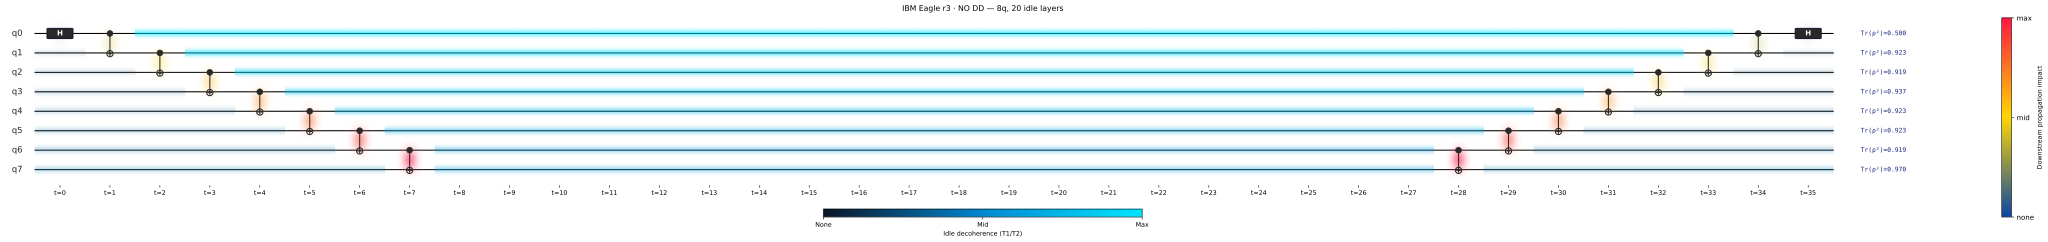

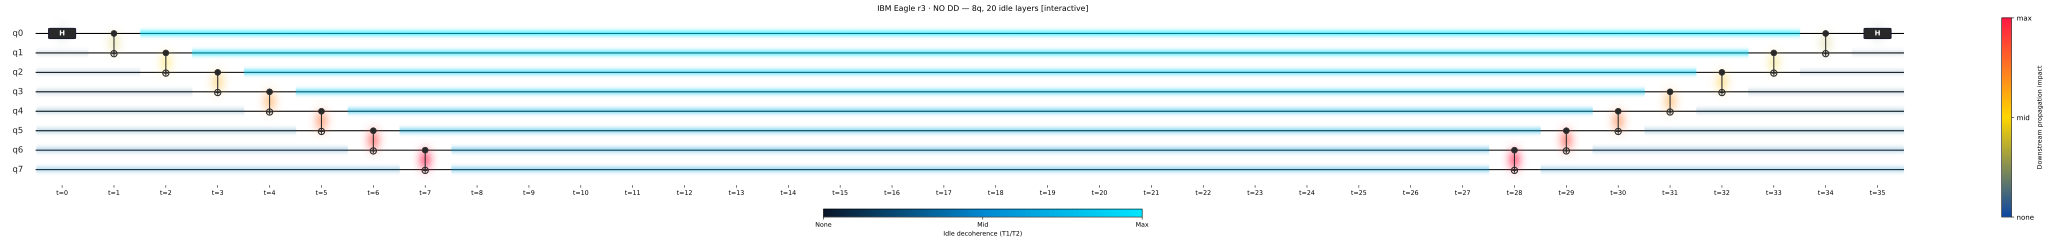

GIF saved → outputs/dd_baseline_8q.gif
GIF → outputs/dd_baseline_8q.gif


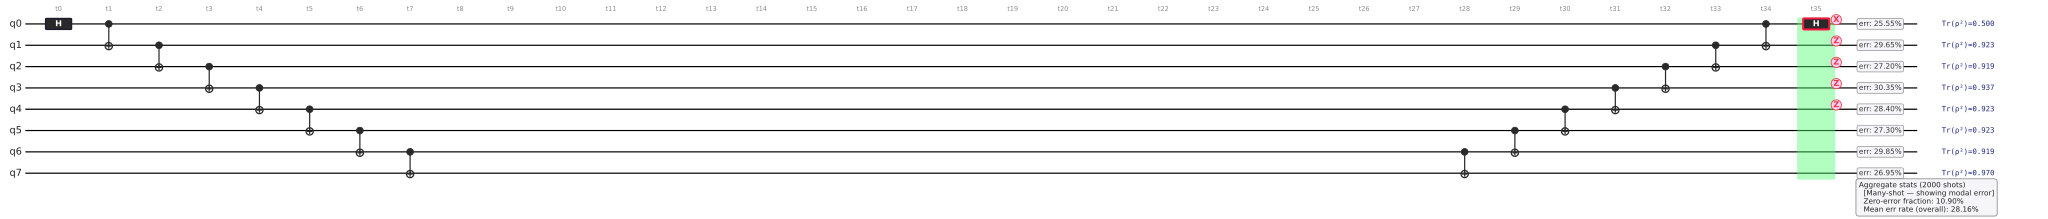

In [5]:
visualize_circuit(
    circuit_baseline, result_dd_baseline, noise_dd_baseline,
    rho_base, pur_base,
    label=f"NO DD — {N_DD}q, {STORAGE_LAYERS} idle layers",
    gif_name="dd_baseline_8q",
)

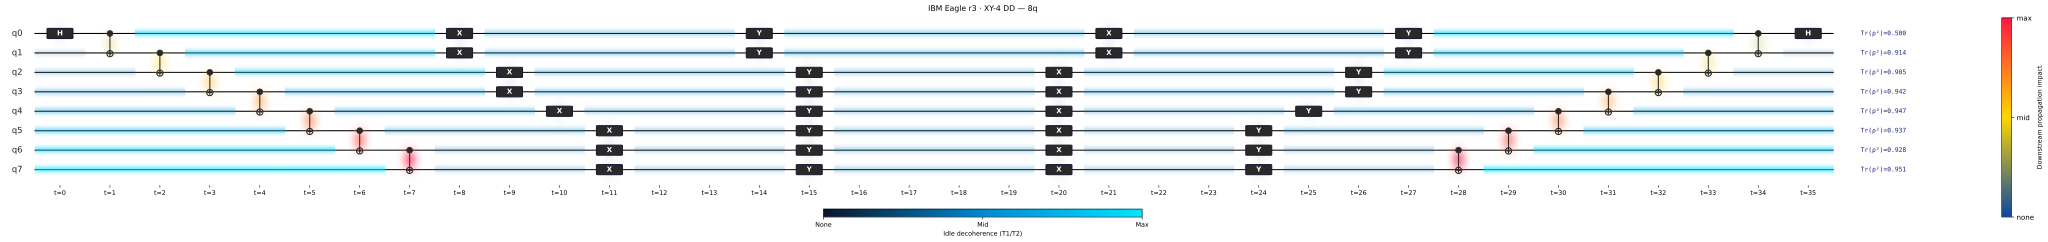

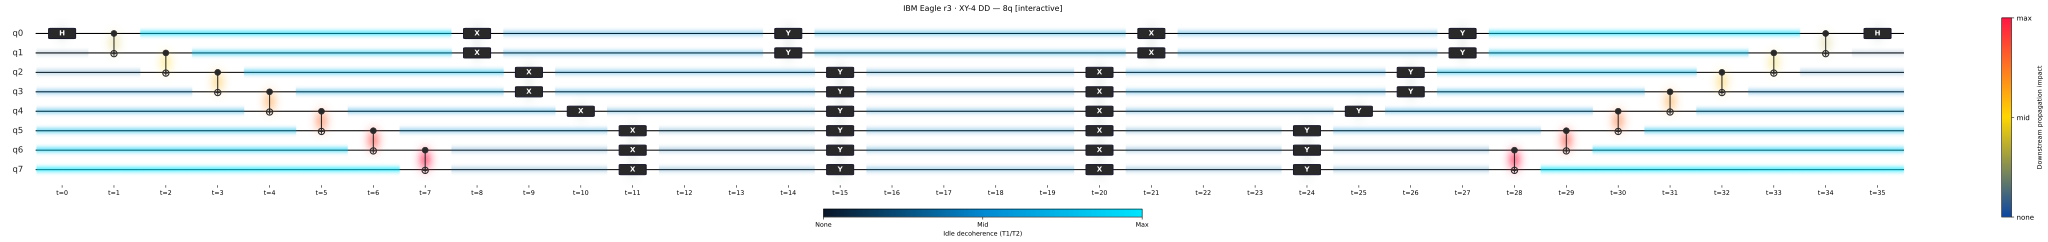

GIF saved → outputs/dd_xy4_8q.gif
GIF → outputs/dd_xy4_8q.gif


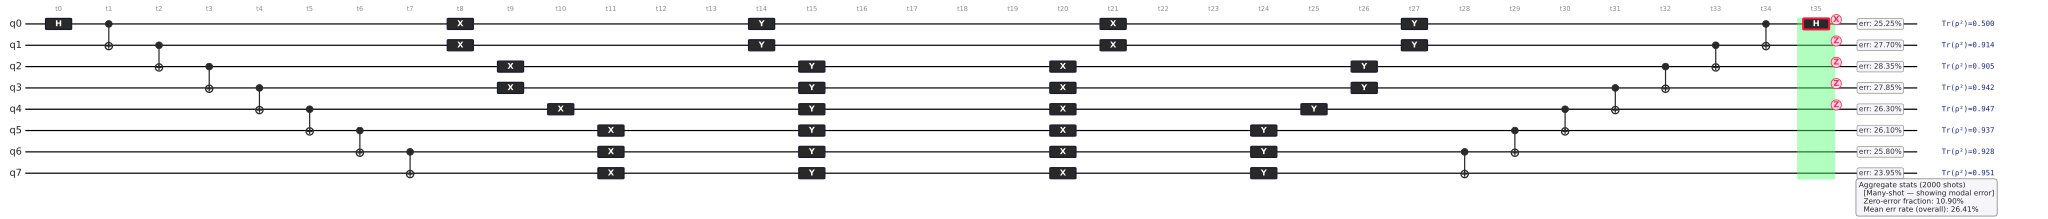

In [6]:
visualize_circuit(
    circuit_xy4, result_dd_xy4, noise_dd_xy4,
    rho_xy4, pur_xy4,
    label=f"XY-4 DD — {N_DD}q",
    gif_name="dd_xy4_8q",
)

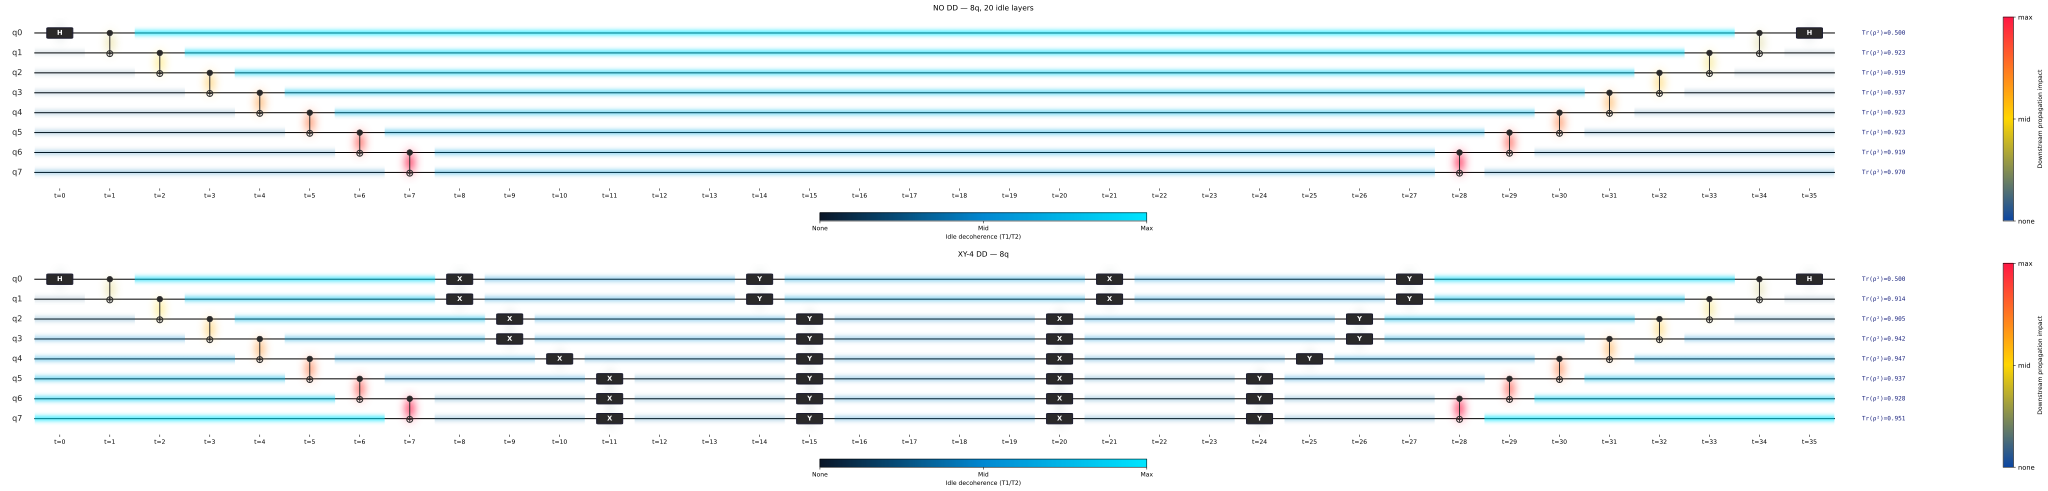

Comparison chart → outputs/dd_heatmap_comparison.png


In [7]:
# Combined comparison: Baseline (top) vs XY-4 DD (bottom) — heatmap + purity panel
from noisiq.visualization.theme import (
    CIRCUIT_WIDTH_PER_LAYER,
    CIRCUIT_HEIGHT_PER_QUBIT,
    CIRCUIT_MIN_WIDTH,
    CIRCUIT_BASE_HEIGHT_PAD,
    HEATMAP_FIGSIZE_WIDTH_PAD,
    HEATMAP_FIGSIZE_HEIGHT_PAD,
)

n_layers_base = max(op.t for op in circuit_baseline.operations) + 1
n_layers_xy4  = max(op.t for op in circuit_xy4.operations) + 1
n_layers_max  = max(n_layers_base, n_layers_xy4)

fig_w = max(CIRCUIT_MIN_WIDTH, CIRCUIT_WIDTH_PER_LAYER * n_layers_max) + HEATMAP_FIGSIZE_WIDTH_PAD + 2.0
row_h = CIRCUIT_HEIGHT_PER_QUBIT * N_DD + CIRCUIT_BASE_HEIGHT_PAD + HEATMAP_FIGSIZE_HEIGHT_PAD
fig_h = row_h * 2 + 0.5

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(fig_w, fig_h))

plot_error_heatmap(
    result_dd_baseline, circuit_baseline,
    noise_config=noise_dd_baseline,
    title=f"NO DD \u2014 {N_DD}q, {STORAGE_LAYERS} idle layers",
    ax=ax_top,
)
add_purity_panel(fig, ax_top, rho_base, N_DD)

plot_error_heatmap(
    result_dd_xy4, circuit_xy4,
    noise_config=noise_dd_xy4,
    title=f"XY-4 DD \u2014 {N_DD}q",
    ax=ax_bot,
)
add_purity_panel(fig, ax_bot, rho_xy4, N_DD)

plt.tight_layout(h_pad=1.5)
plt.savefig("outputs/dd_heatmap_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Comparison chart \u2192 outputs/dd_heatmap_comparison.png")


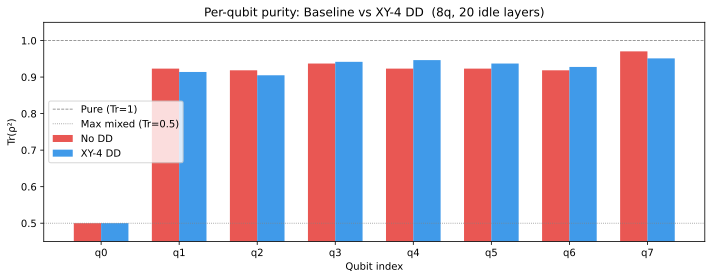

Purity comparison chart → outputs/dd_purity_comparison.png


In [8]:
# Side-by-side purity bar chart: Baseline vs XY-4 DD
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(N_DD)
w = 0.35
ax.bar(x - w / 2, pur_base, width=w, label="No DD",   color="#E53935", alpha=0.85)
ax.bar(x + w / 2, pur_xy4,  width=w, label="XY-4 DD", color="#1E88E5", alpha=0.85)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="Pure (Tr=1)")
ax.axhline(0.5, color="gray", linestyle=":",  linewidth=0.8, label="Max mixed (Tr=0.5)")
ax.set_xlabel("Qubit index")
ax.set_ylabel("Tr(ρ²)")
ax.set_title(
    f"Per-qubit purity: Baseline vs XY-4 DD  "
    f"({N_DD}q, {STORAGE_LAYERS} idle layers)"
)
ax.set_xticks(x)
ax.set_xticklabels([f"q{i}" for i in range(N_DD)])
ax.legend()
ax.set_ylim(0.45, 1.05)
plt.tight_layout()
plt.savefig("outputs/dd_purity_comparison.png", dpi=120)
plt.show()
print("Purity comparison chart → outputs/dd_purity_comparison.png")

---

## Additional DD Sequences: Hahn-Echo, CPMG, and XY-8

Three more sequences compared against the baseline and XY-4 results above.
All three reuse the same `build_sparse_dd_circuit` skeleton — only the
`apply_dd(sequence=...)` call changes.

| Sequence | Pulses | Suppresses | Notes |
|---|---|---|---|
| **Hahn-echo** | `X` | Z dephasing | Simplest single-pulse refocusing |
| **CPMG** | `X·X` | Z dephasing | Two evenly-spaced X pulses; better low-frequency noise rejection than Hahn |
| **XY-8** | `X·Y·X·Y·Y·X·Y·X` | Universal (X and Z) | Higher-order than XY-4; 8 pulses must fit in the storage window (`idle_threshold=8`) |

**Build order is identical to XY-4:**
1. `apply_dd(circuit_dd_sparse, sequence=...)` → sparse circuit with DD pulses inserted
2. `fill_idle_with_identities(...)` → IDLE ops added so noise ticks during remaining idle slots
3. `demo_profile_dd.to_noise_model(...)` + `ManyShotRunner` / `TrajectoryBackend` → same as above

In [9]:
# Build sparse → apply DD → fill idle, for all three new sequences.
# Reuses circuit_dd_sparse (the same 8q GHZ+storage+inv-GHZ skeleton).

circuit_hahn_sparse = apply_dd(circuit_dd_sparse, sequence="hahn", idle_threshold=1)
circuit_cpmg_sparse = apply_dd(circuit_dd_sparse, sequence="CPMG", idle_threshold=2)
circuit_xy8_sparse  = apply_dd(circuit_dd_sparse, sequence="XY-8", idle_threshold=8)

circuit_hahn = fill_idle_with_identities(circuit_hahn_sparse, gate_times)
circuit_cpmg = fill_idle_with_identities(circuit_cpmg_sparse, gate_times)
circuit_xy8  = fill_idle_with_identities(circuit_xy8_sparse,  gate_times)

print(f"Hahn ops (idle-filled): {len(circuit_hahn.operations)}")
print(f"CPMG ops (idle-filled): {len(circuit_cpmg.operations)}")
print(f"XY-8 ops (idle-filled): {len(circuit_xy8.operations)}")

Hahn ops (idle-filled): 274
CPMG ops (idle-filled): 274
XY-8 ops (idle-filled): 274


In [10]:
noise_hahn = demo_profile_dd.to_noise_model(circuit_hahn, mode="t2", representation="pauli_twirl")
noise_cpmg = demo_profile_dd.to_noise_model(circuit_cpmg, mode="t2", representation="pauli_twirl")
noise_xy8  = demo_profile_dd.to_noise_model(circuit_xy8,  mode="t2", representation="pauli_twirl")

result_hahn = ManyShotRunner().run(circuit_hahn, n_shots=N_SHOTS, noise_config=noise_hahn, seed=42)
result_cpmg = ManyShotRunner().run(circuit_cpmg, n_shots=N_SHOTS, noise_config=noise_cpmg, seed=42)
result_xy8  = ManyShotRunner().run(circuit_xy8,  n_shots=N_SHOTS, noise_config=noise_xy8,  seed=42)

print(f"Zero-error (baseline): {result_dd_baseline.zero_error_fraction:.4f}  (reference)")
print(f"Zero-error (XY-4 DD):  {result_dd_xy4.zero_error_fraction:.4f}  (reference)")
print()
print(f"Zero-error (Hahn-echo): {result_hahn.zero_error_fraction:.4f}")
print(f"Zero-error (CPMG):      {result_cpmg.zero_error_fraction:.4f}")
print(f"Zero-error (XY-8 DD):   {result_xy8.zero_error_fraction:.4f}")

rho_hahn, pur_hahn = run_purity_pass(circuit_hahn, noise_hahn, N_DD, "Hahn-echo")
rho_cpmg, pur_cpmg = run_purity_pass(circuit_cpmg, noise_cpmg, N_DD, "CPMG")
rho_xy8,  pur_xy8  = run_purity_pass(circuit_xy8,  noise_xy8,  N_DD, "XY-8 DD")

Zero-error (baseline): 0.1090  (reference)
Zero-error (XY-4 DD):  0.1090  (reference)

Zero-error (Hahn-echo): 0.1050
Zero-error (CPMG):      0.1075
Zero-error (XY-8 DD):   0.1350

──────────────────────────────────────────────────
Per-qubit purity  [Hahn-echo]
  q 0  Tr(ρ²) = 0.5000  ██████████
  q 1  Tr(ρ²) = 0.9005  ██████████████████
  q 2  Tr(ρ²) = 0.9095  ██████████████████
  q 3  Tr(ρ²) = 0.9050  ██████████████████
  q 4  Tr(ρ²) = 0.9371  ██████████████████
  q 5  Tr(ρ²) = 0.9465  ██████████████████
  q 6  Tr(ρ²) = 0.9371  ██████████████████
  q 7  Tr(ρ²) = 0.9704  ███████████████████
──────────────────────────────────────────────────


──────────────────────────────────────────────────
Per-qubit purity  [CPMG]
  q 0  Tr(ρ²) = 0.5003  ██████████
  q 1  Tr(ρ²) = 0.9140  ██████████████████
  q 2  Tr(ρ²) = 0.9186  ██████████████████
  q 3  Tr(ρ²) = 0.9324  ██████████████████
  q 4  Tr(ρ²) = 0.9186  ██████████████████
  q 5  Tr(ρ²) = 0.9186  ██████████████████
  q 6  Tr(ρ²) = 0.9186

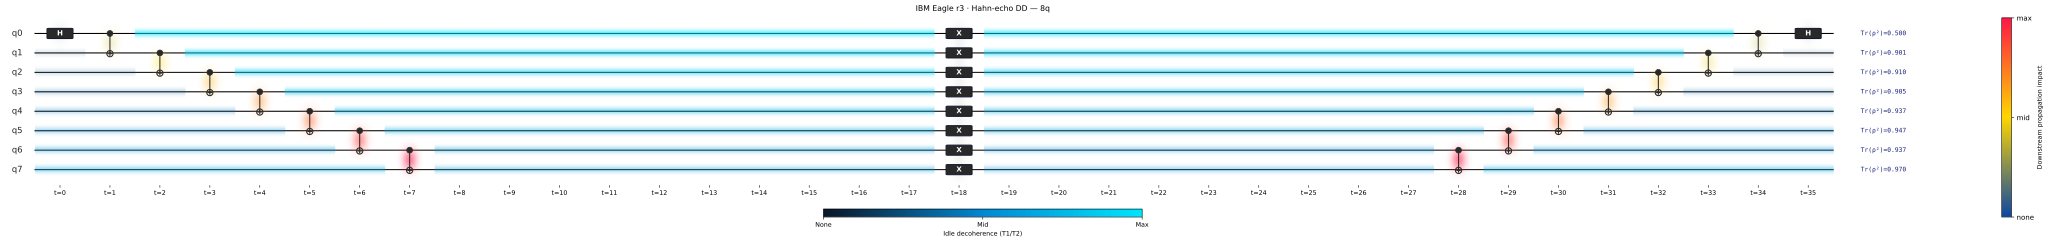

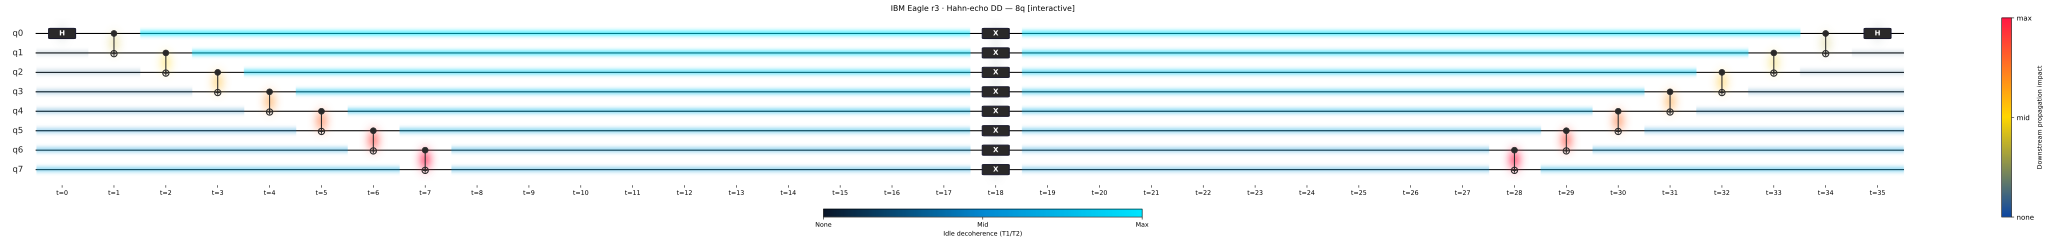

GIF saved → outputs/dd_hahn_8q.gif
GIF → outputs/dd_hahn_8q.gif


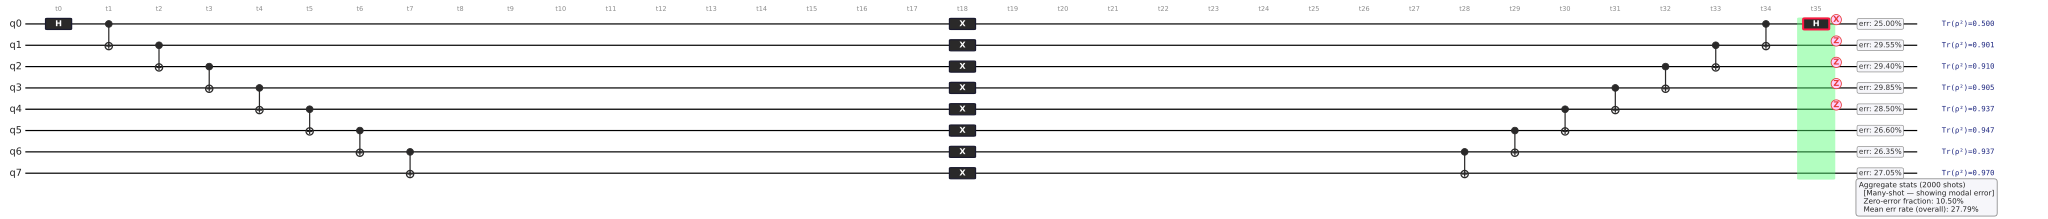

In [11]:
visualize_circuit(
    circuit_hahn, result_hahn, noise_hahn,
    rho_hahn, pur_hahn,
    label=f"Hahn-echo DD — {N_DD}q",
    gif_name="dd_hahn_8q",
)

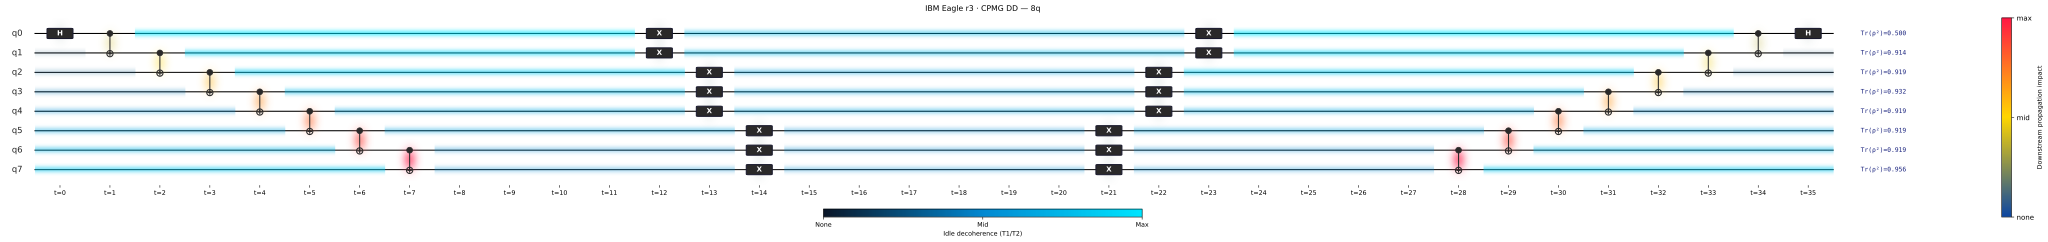

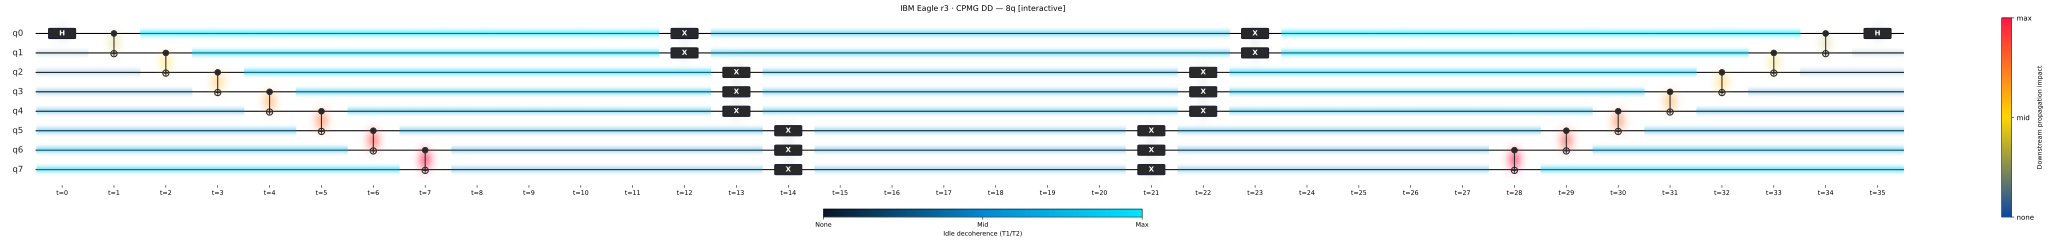

GIF saved → outputs/dd_cpmg_8q.gif
GIF → outputs/dd_cpmg_8q.gif


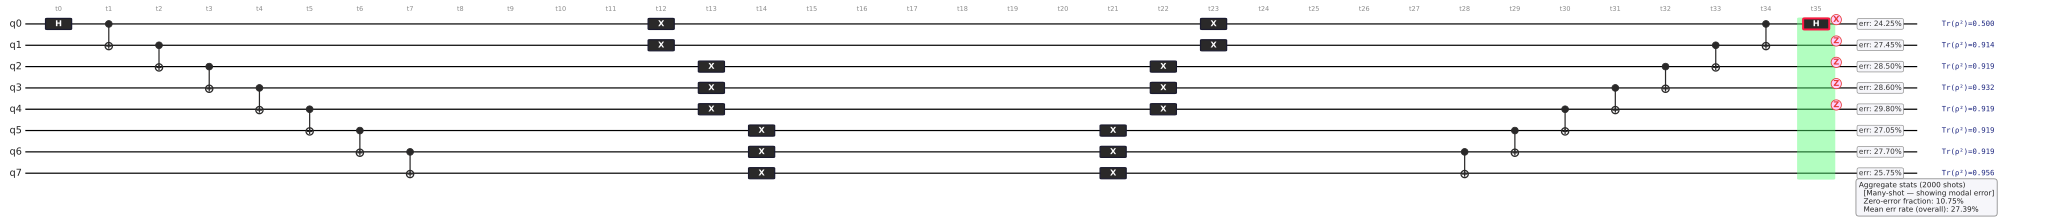

In [12]:
visualize_circuit(
    circuit_cpmg, result_cpmg, noise_cpmg,
    rho_cpmg, pur_cpmg,
    label=f"CPMG DD — {N_DD}q",
    gif_name="dd_cpmg_8q",
)

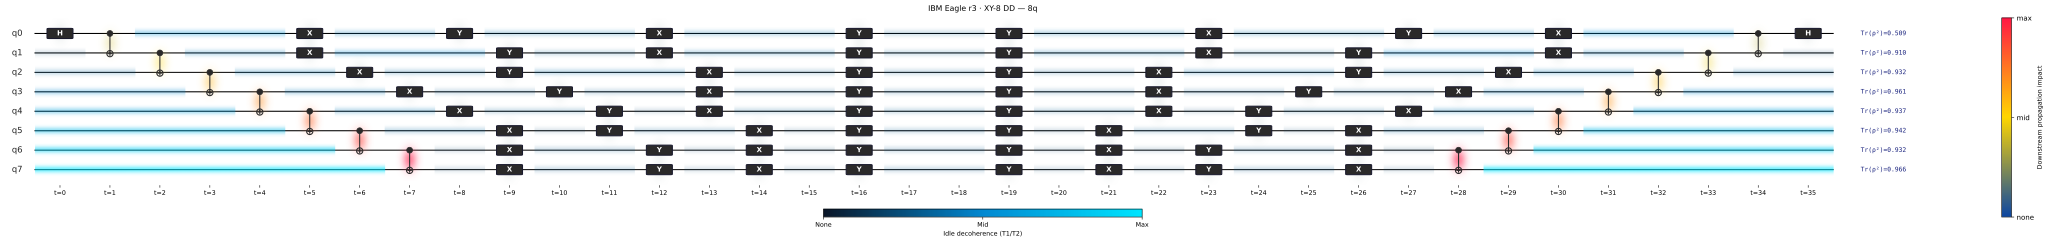

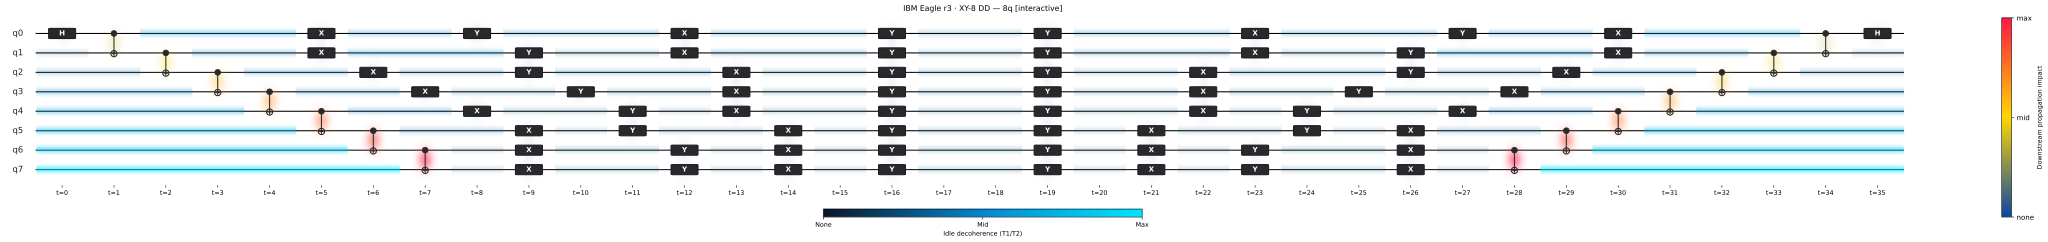

GIF saved → outputs/dd_xy8_8q.gif
GIF → outputs/dd_xy8_8q.gif


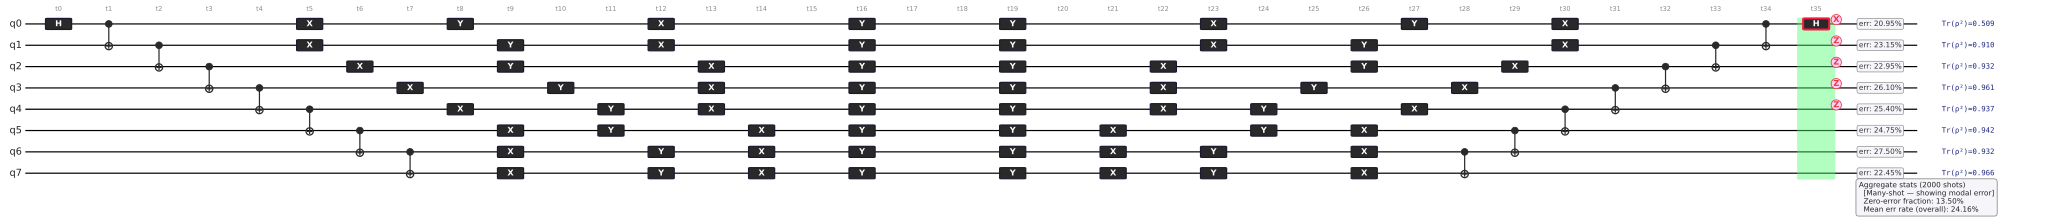

In [13]:
visualize_circuit(
    circuit_xy8, result_xy8, noise_xy8,
    rho_xy8, pur_xy8,
    label=f"XY-8 DD — {N_DD}q",
    gif_name="dd_xy8_8q",
)

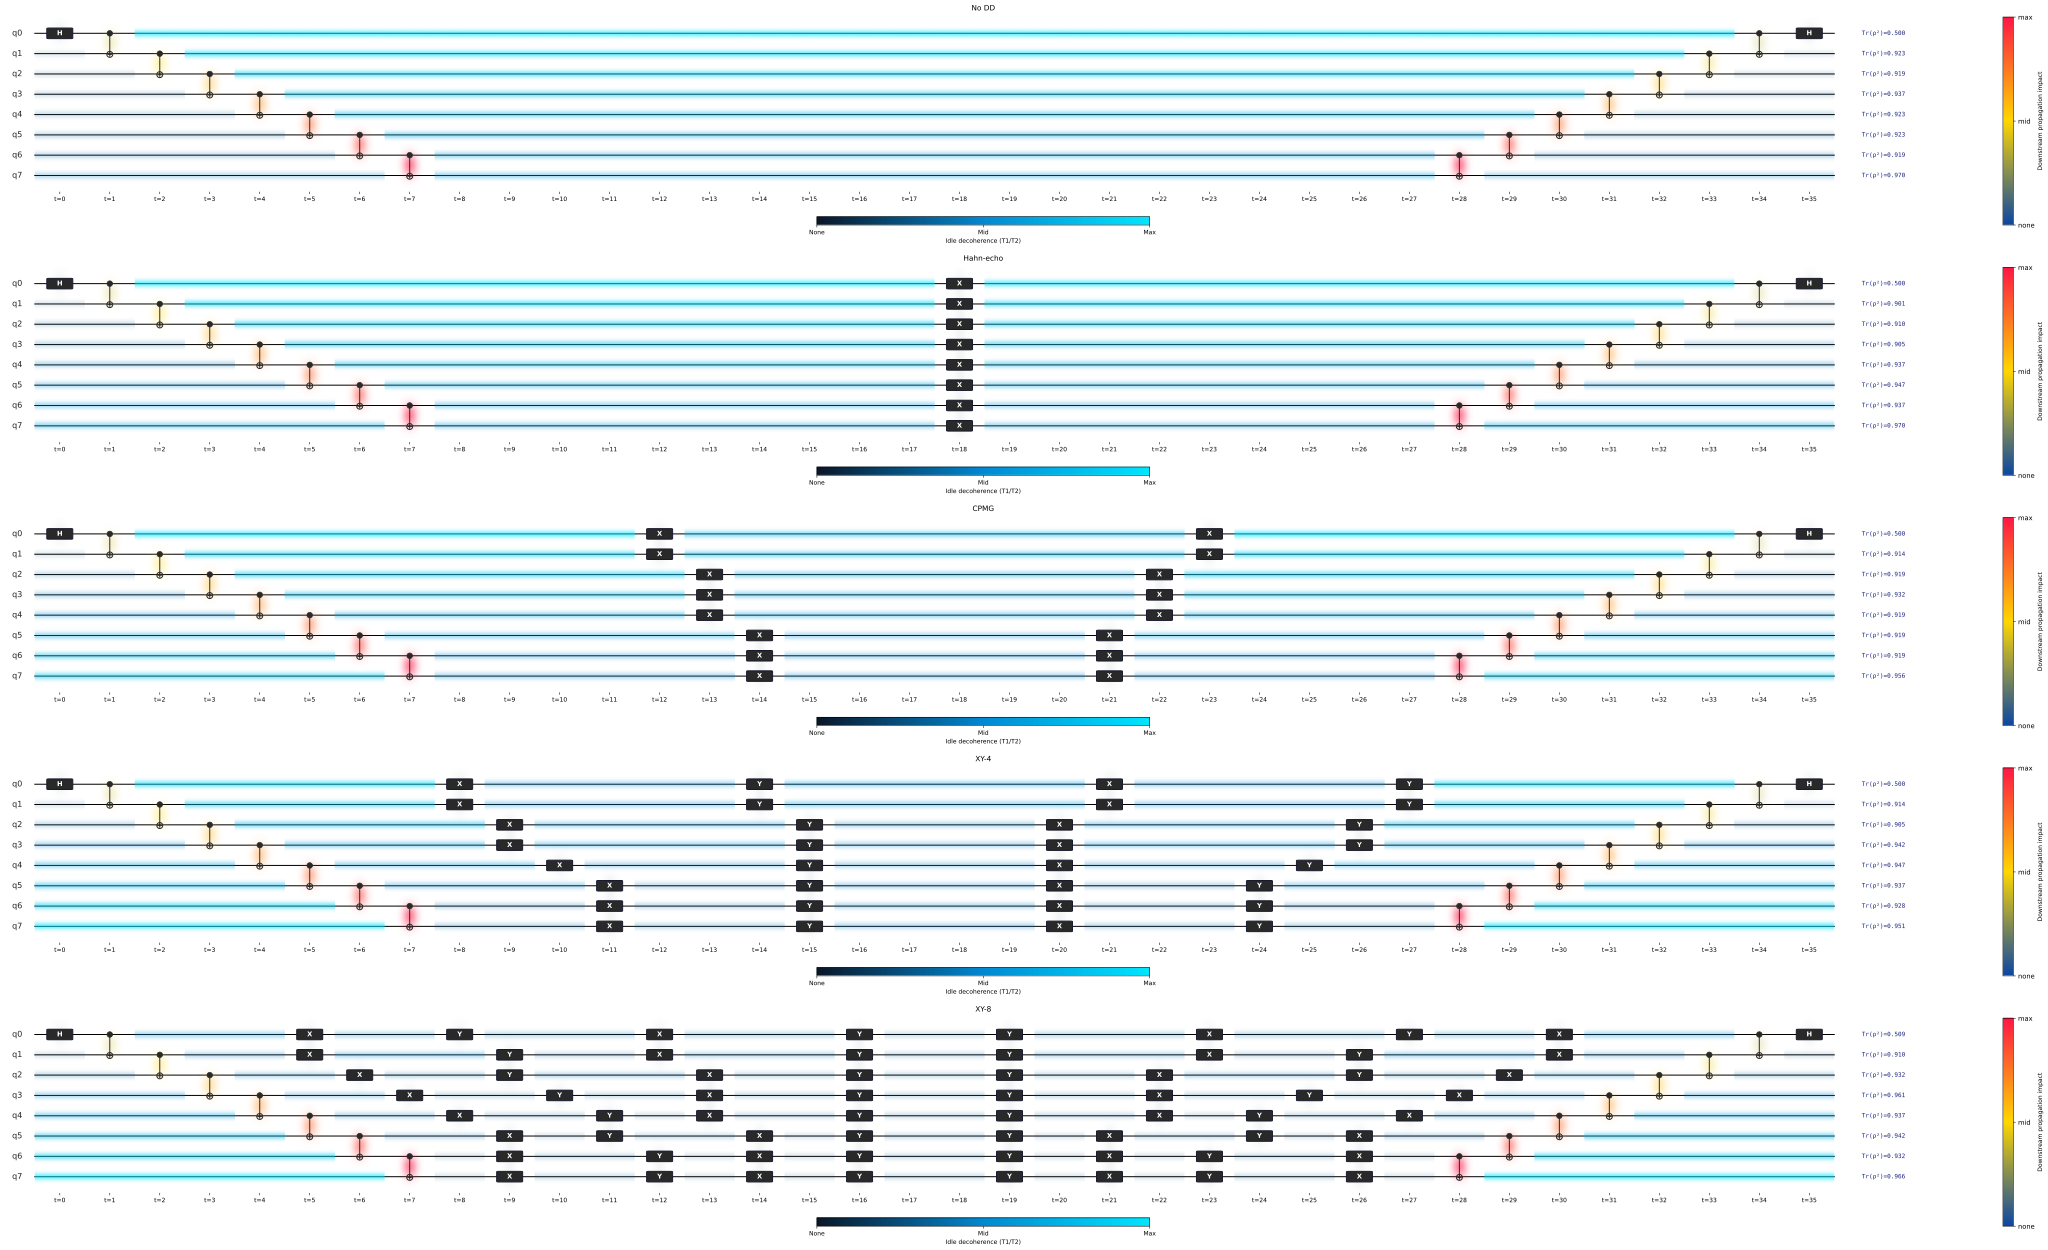

5-way heatmap comparison → outputs/dd_heatmap_all5.png


In [14]:
# ── 5-way heatmap comparison ────────────────────────────────────────────────
all_circuits_5 = [circuit_baseline, circuit_hahn, circuit_cpmg, circuit_xy4, circuit_xy8]
all_results_5  = [result_dd_baseline, result_hahn, result_cpmg, result_dd_xy4, result_xy8]
all_noises_5   = [noise_dd_baseline,  noise_hahn,  noise_cpmg,  noise_dd_xy4, noise_xy8]
all_rhos_5     = [rho_base, rho_hahn, rho_cpmg, rho_xy4, rho_xy8]
all_labels_5   = ["No DD", "Hahn-echo", "CPMG", "XY-4", "XY-8"]

n_layers_max5 = max(max(op.t for op in c.operations) + 1 for c in all_circuits_5)
fig_w5 = max(CIRCUIT_MIN_WIDTH, CIRCUIT_WIDTH_PER_LAYER * n_layers_max5) + HEATMAP_FIGSIZE_WIDTH_PAD + 2.0
row_h5 = CIRCUIT_HEIGHT_PER_QUBIT * N_DD + CIRCUIT_BASE_HEIGHT_PAD + HEATMAP_FIGSIZE_HEIGHT_PAD
fig5, axes5 = plt.subplots(5, 1, figsize=(fig_w5, row_h5 * 5 + 1.5))

for ax, circ, res, noise, rho, lbl in zip(
    axes5, all_circuits_5, all_results_5, all_noises_5, all_rhos_5, all_labels_5
):
    plot_error_heatmap(res, circ, noise_config=noise, title=lbl, ax=ax)
    add_purity_panel(fig5, ax, rho, N_DD)

plt.tight_layout(h_pad=1.5)
plt.savefig("outputs/dd_heatmap_all5.png", dpi=120, bbox_inches="tight")
plt.show()
print("5-way heatmap comparison → outputs/dd_heatmap_all5.png")

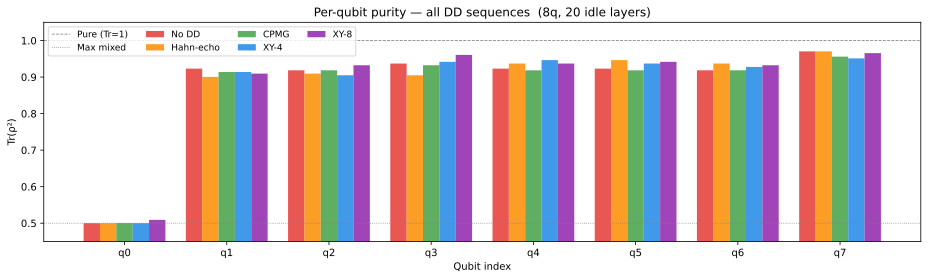

5-way purity chart → outputs/dd_purity_all5.png


In [15]:
# ── 5-way purity bar chart: No DD / Hahn / CPMG / XY-4 / XY-8 ──────────────
all_purs_5   = [pur_base, pur_hahn, pur_cpmg, pur_xy4, pur_xy8]
colors_5     = ["#E53935", "#FB8C00", "#43A047", "#1E88E5", "#8E24AA"]
labels_bar_5 = ["No DD", "Hahn-echo", "CPMG", "XY-4", "XY-8"]

fig, ax = plt.subplots(figsize=(13, 4))
x = np.arange(N_DD)
n_bars = len(all_purs_5)
bar_w = 0.80 / n_bars

for i, (purs, color, lbl) in enumerate(zip(all_purs_5, colors_5, labels_bar_5)):
    offset = (i - (n_bars - 1) / 2) * bar_w
    ax.bar(x + offset, purs, width=bar_w, label=lbl, color=color, alpha=0.85)

ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="Pure (Tr=1)")
ax.axhline(0.5, color="gray", linestyle=":",  linewidth=0.8, label="Max mixed")
ax.set_xlabel("Qubit index")
ax.set_ylabel("Tr(ρ²)")
ax.set_title(
    f"Per-qubit purity — all DD sequences  ({N_DD}q, {STORAGE_LAYERS} idle layers)"
)
ax.set_xticks(x)
ax.set_xticklabels([f"q{i}" for i in range(N_DD)])
ax.legend(ncol=4, fontsize=9)
ax.set_ylim(0.45, 1.05)
plt.tight_layout()
plt.savefig("outputs/dd_purity_all5.png", dpi=120)
plt.show()
print("5-way purity chart → outputs/dd_purity_all5.png")